# GlitchGAN Evaluation

Evaluates the **GlitchGAN** generator (TensorFlow/Keras, `cDVGAN` architecture) on LIGO glitch data.

Sections:
1. Load real data
2. Load GlitchGAN generator
3. Generate signals — waveform plots
4. UMAP dimensionality reduction
5. Gravity Spy classification
6. Summary

## Configuration

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()   # run from project root
DATA_DIR     = PROJECT_ROOT / "data"
PLOTS_DIR    = PROJECT_ROOT / "evaluation_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Generator checkpoint to evaluate.
# Point to the new training output once the fresh run is complete:
#   GENERATOR_PATH = PROJECT_ROOT / "GAN_outputs_tf" / "cDVGAN" / "monitor" / "generator_210.keras"
GENERATOR_PATH = PROJECT_ROOT / "weights" / "tensorflow" / "generator_210_keras3.keras"
GENERATOR_EPOCH = 210

# Generation parameters
NOISE_DIM         = 100
NUM_CLASSES       = 7
SAMPLES_PER_CLASS = 100
LABEL_ORDER = [
    "Blip", "Fast_Scattering", "Koi_Fish",
    "Low_Frequency_Burst", "Scattered_Light", "Tomte", "Whistle"
]

print("Project root    :", PROJECT_ROOT)
print("Generator path  :", GENERATOR_PATH)
print("Samples/class   :", SAMPLES_PER_CLASS)

Project root    : /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor
Generator path  : /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/weights/tensorflow/generator_210_keras3.keras
Samples/class   : 100


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

## 1. Load Real Data

In [3]:
X_real   = np.load(DATA_DIR / "glitch_GAN_samples_scaled_balanced.npy")
y_onehot = np.load(DATA_DIR / "glitch_GAN_labels_balanced.npy")
y_real   = np.array(LABEL_ORDER)[np.argmax(y_onehot, axis=1)]

print(f"Real signals : {X_real.shape}")
print(f"Classes      : {LABEL_ORDER}")

Real signals : (35000, 8192)
Classes      : ['Blip', 'Fast_Scattering', 'Koi_Fish', 'Low_Frequency_Burst', 'Scattered_Light', 'Tomte', 'Whistle']


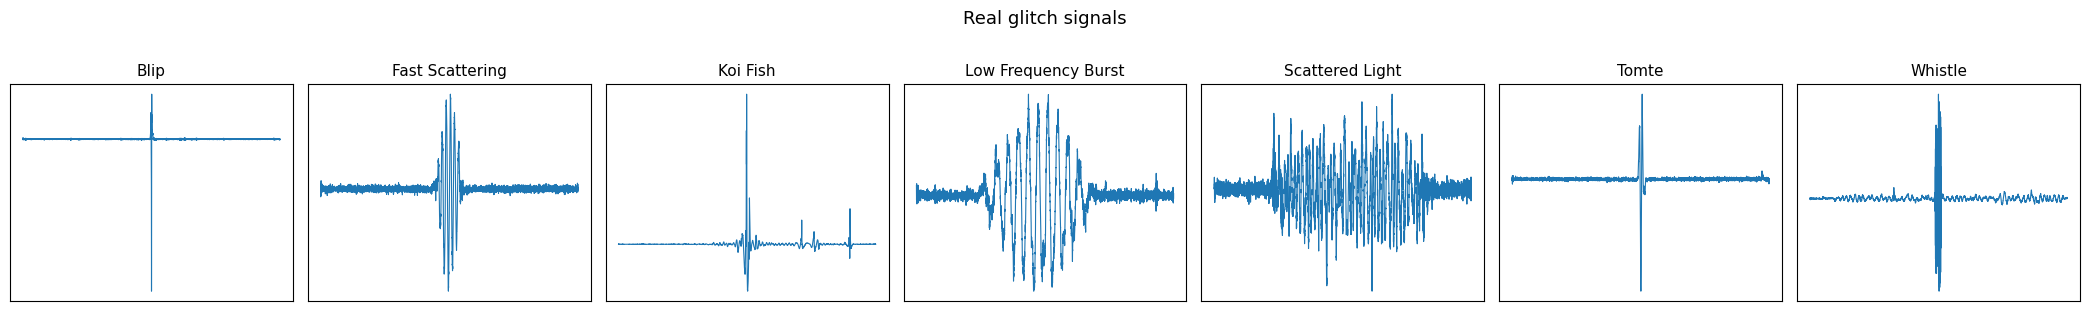

In [4]:
def plot_per_class_row(X, y, label_order, color, title=None, save_name=None):
    fig, axes = plt.subplots(1, len(label_order), figsize=(3 * len(label_order), 3))
    for i, lbl in enumerate(label_order):
        idx = np.where(y == lbl)[0]
        axes[i].plot(X[np.random.choice(idx)], lw=0.8, color=color)
        axes[i].set_xticks([]); axes[i].set_yticks([])
        axes[i].set_title(lbl.replace("_", " "), fontsize=11)
    if title:
        fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    if save_name:
        plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()

plot_per_class_row(X_real, y_real, LABEL_ORDER, color="C0",
                   title="Real glitch signals", save_name="real_waveforms_row")

## 2. Load GlitchGAN

`GlitchGAN` is the application-level class: a `cDVGAN` (WGAN-GP with derivative discriminator) with LIGO-specific defaults (`signal_length=8192`, `num_classes=7`) baked in.

For evaluation we only need the generator sub-model, so we load the saved `.keras` weights directly into the `GlitchGAN` generator slot.

In [5]:
import keras
from cdvgan.tf import GlitchGAN

gan = GlitchGAN()
gan.generator = keras.models.load_model(str(GENERATOR_PATH), compile=False)

print(f"Loaded GlitchGAN generator from: {GENERATOR_PATH}")
gan.generator.summary(line_length=80)

Loaded GlitchGAN generator from: /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/weights/tensorflow/generator_210_keras3.keras


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, 7)         │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ input_layer           │ (None, 100)       │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, 32)        │         224 │ input_layer_1[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate           │ (None, 132)       │           0 │ input_layer[0][0], │
│ (Concatenate)         │                   │             │ dense[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_1 (Dense)       │ (None, 4096)      │     540,672 │ concatenate[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, 4096)      │           0 │ dense_1[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ reshape (Reshape)     │ (None, 256, 16)   │           0 │ re_lu[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ up_sampling1d         │ (None, 512, 16)   │           0 │ reshape[0][0]      │
│ (UpSampling1D)        │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d (Conv1D)       │ (None, 512, 512)  │     147,456 │ up_sampling1d[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 512, 512)  │       2,048 │ conv1d[0][0]       │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, 512, 512)  │           0 │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ up_sampling1d_1       │ (None, 1024, 512) │           0 │ re_lu_1[0][0]      │
│ (UpSampling1D)        │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d_1 (Conv1D)     │ (None, 1024, 256) │   2,359,296 │ up_sampling1d_1[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 1024, 256) │       1,024 │ conv1d_1[0][0]     │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, 1024, 256) │           0 │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ up_sampling1d_2       │ (None, 2048, 256) │           0 │ re_lu_2[0][0]      │
│ (UpSampling1D)        │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d_2 (Conv1D)     │ (None, 2048, 128) │     589,824 │ up_sampling1d_2[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 2048, 128) │         512 │ conv1d_2[0][0]     │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, 2048, 128) │           0 │ batch_normalizati… │
├───────────────────────┼──────

 Total params: 3,789,920 (14.46 MB)

 Trainable params: 3,788,000 (14.45 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 3. Generate Signals

In [6]:
from cdvgan.tf.utils import generate_examples

X_fake, class_vecs = generate_examples(
    gan,
    noise_dim=NOISE_DIM,
    num_classes=NUM_CLASSES,
    num_signals=NUM_CLASSES * SAMPLES_PER_CLASS,
    sampling="vertex",
)
y_fake = np.array(LABEL_ORDER)[np.argmax(class_vecs, axis=1)]

print(f"Generated : {X_fake.shape}  ({SAMPLES_PER_CLASS} per class)")

Generated : (700, 8192)  (100 per class)


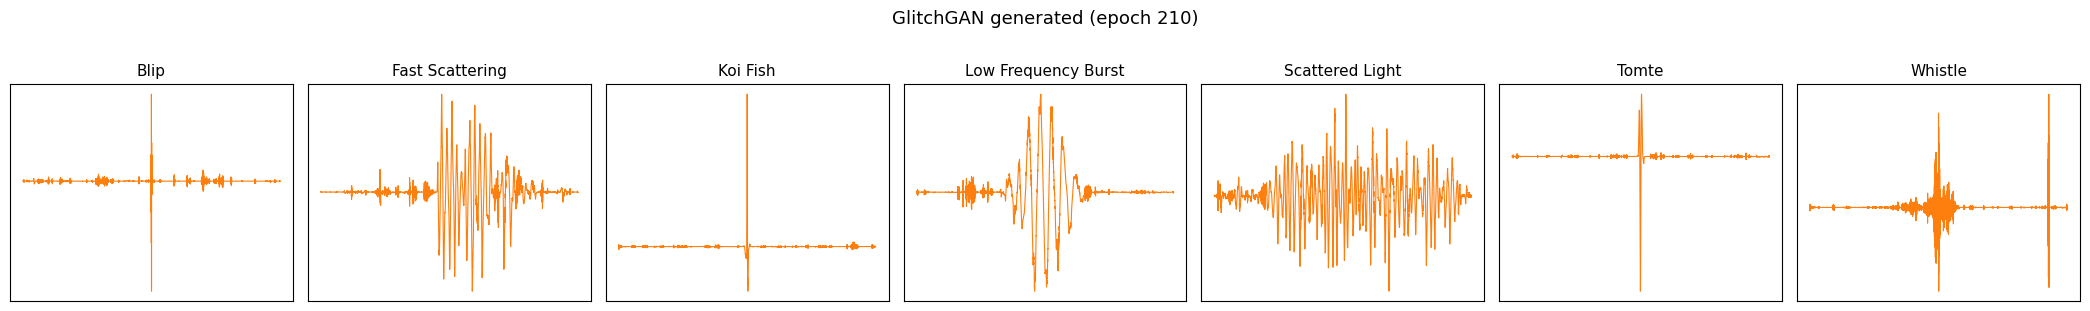

In [7]:
plot_per_class_row(X_fake, y_fake, LABEL_ORDER, color="C1",
                   title=f"GlitchGAN generated (epoch {GENERATOR_EPOCH})",
                   save_name=f"glitchgan_waveforms_ep{GENERATOR_EPOCH}")

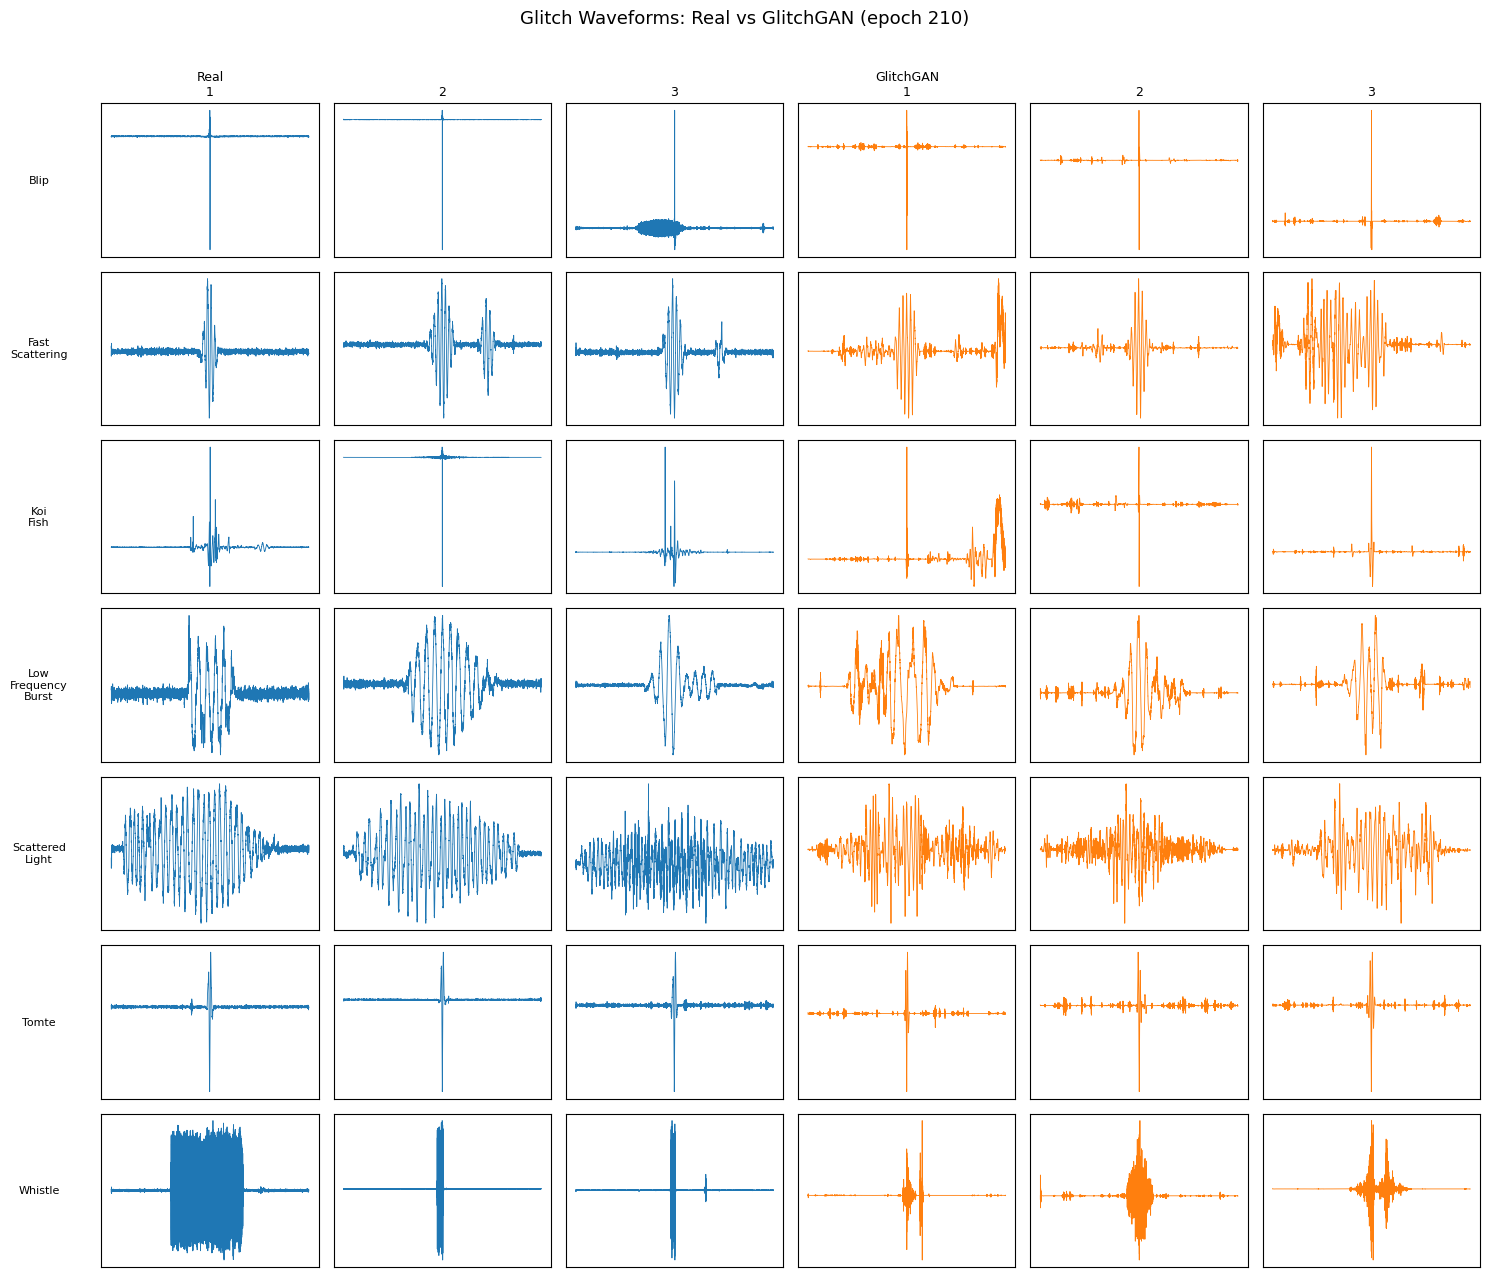

In [8]:
# Side-by-side comparison grid: rows = glitch class, columns = Real / GlitchGAN
def plot_comparison_grid(sources, label_order, n_examples=5, save_name=None):
    n_sources = len(sources)
    n_classes = len(label_order)
    fig, axes = plt.subplots(
        n_classes, n_sources * n_examples,
        figsize=(2.5 * n_sources * n_examples, 1.8 * n_classes)
    )
    for col_group, (X, y, title, color) in enumerate(sources):
        for row, lbl in enumerate(label_order):
            idx    = np.where(y == lbl)[0]
            chosen = np.random.choice(idx, min(n_examples, len(idx)), replace=False)
            for j, ci in enumerate(chosen):
                col = col_group * n_examples + j
                ax  = axes[row, col]
                ax.plot(X[ci], lw=0.6, color=color)
                ax.set_xticks([]); ax.set_yticks([])
                if row == 0:
                    ax.set_title(f"{title}\n{j+1}" if j == 0 else str(j + 1), fontsize=9)
                if col == 0:
                    ax.set_ylabel(lbl.replace("_", "\n"), fontsize=8,
                                  rotation=0, labelpad=45, va="center")
    plt.suptitle(f"Glitch Waveforms: Real vs GlitchGAN (epoch {GENERATOR_EPOCH})",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    if save_name:
        plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()

plot_comparison_grid(
    sources=[
        (X_real, y_real, "Real",      "C0"),
        (X_fake, y_fake, "GlitchGAN", "C1"),
    ],
    label_order=LABEL_ORDER,
    n_examples=3,
    save_name=f"waveform_comparison_ep{GENERATOR_EPOCH}",
)

### Simplex and Uniform sampling

**Simplex**: class vector drawn from the probability simplex — components are non-negative and sum to 1, so the signal is a blended morphology that still 'belongs' to the class distribution.

**Uniform**: each component drawn independently from [0, 1] — explores the full conditioning space including combinations the model was never explicitly trained on.

In [9]:
X_simplex, cv_simplex = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=NUM_CLASSES * SAMPLES_PER_CLASS, sampling="simplex",
)
y_simplex = np.array(LABEL_ORDER)[np.argmax(cv_simplex, axis=1)]  # dominant class

X_uniform, cv_uniform = generate_examples(
    gan, noise_dim=NOISE_DIM, num_classes=NUM_CLASSES,
    num_signals=NUM_CLASSES * SAMPLES_PER_CLASS, sampling="uniform",
)
y_uniform = np.array(LABEL_ORDER)[np.argmax(cv_uniform, axis=1)]

print(f"Simplex : {X_simplex.shape}")
print(f"Uniform : {X_uniform.shape}")

Simplex : (700, 8192)
Uniform : (700, 8192)


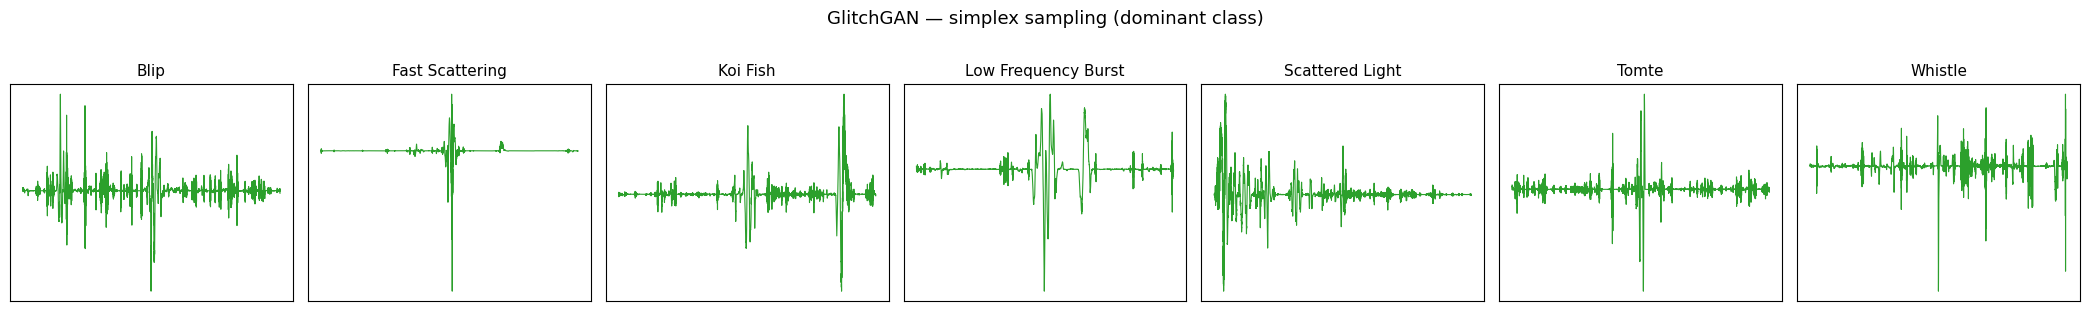

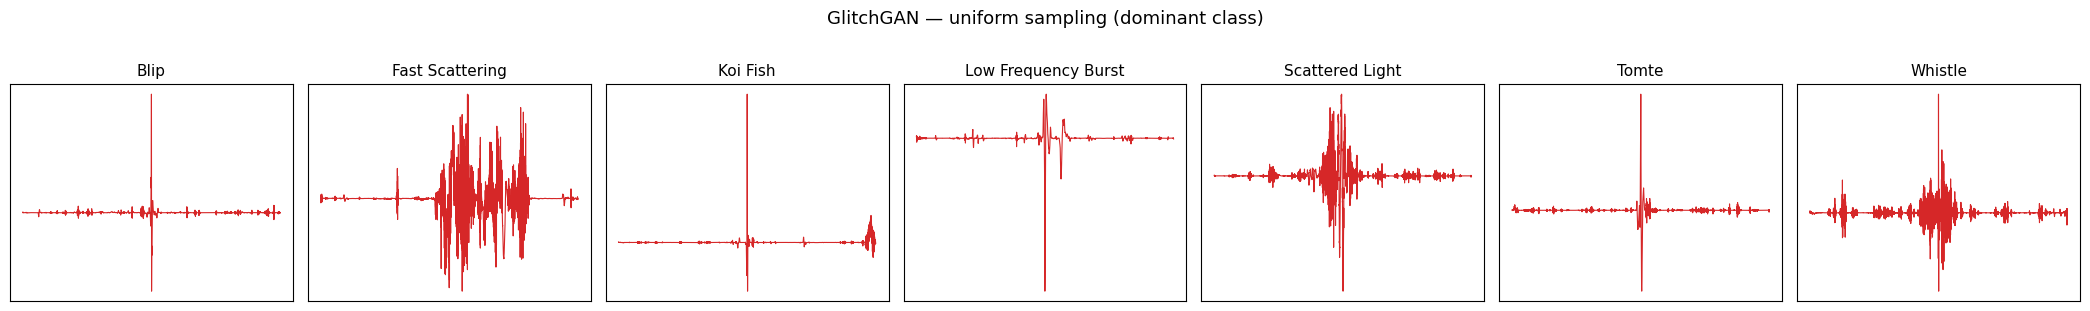

In [10]:
plot_per_class_row(X_simplex, y_simplex, LABEL_ORDER, color="C2",
                   title=f"GlitchGAN — simplex sampling (dominant class)",
                   save_name=f"glitchgan_simplex_ep{GENERATOR_EPOCH}")

plot_per_class_row(X_uniform, y_uniform, LABEL_ORDER, color="C3",
                   title=f"GlitchGAN — uniform sampling (dominant class)",
                   save_name=f"glitchgan_uniform_ep{GENERATOR_EPOCH}")

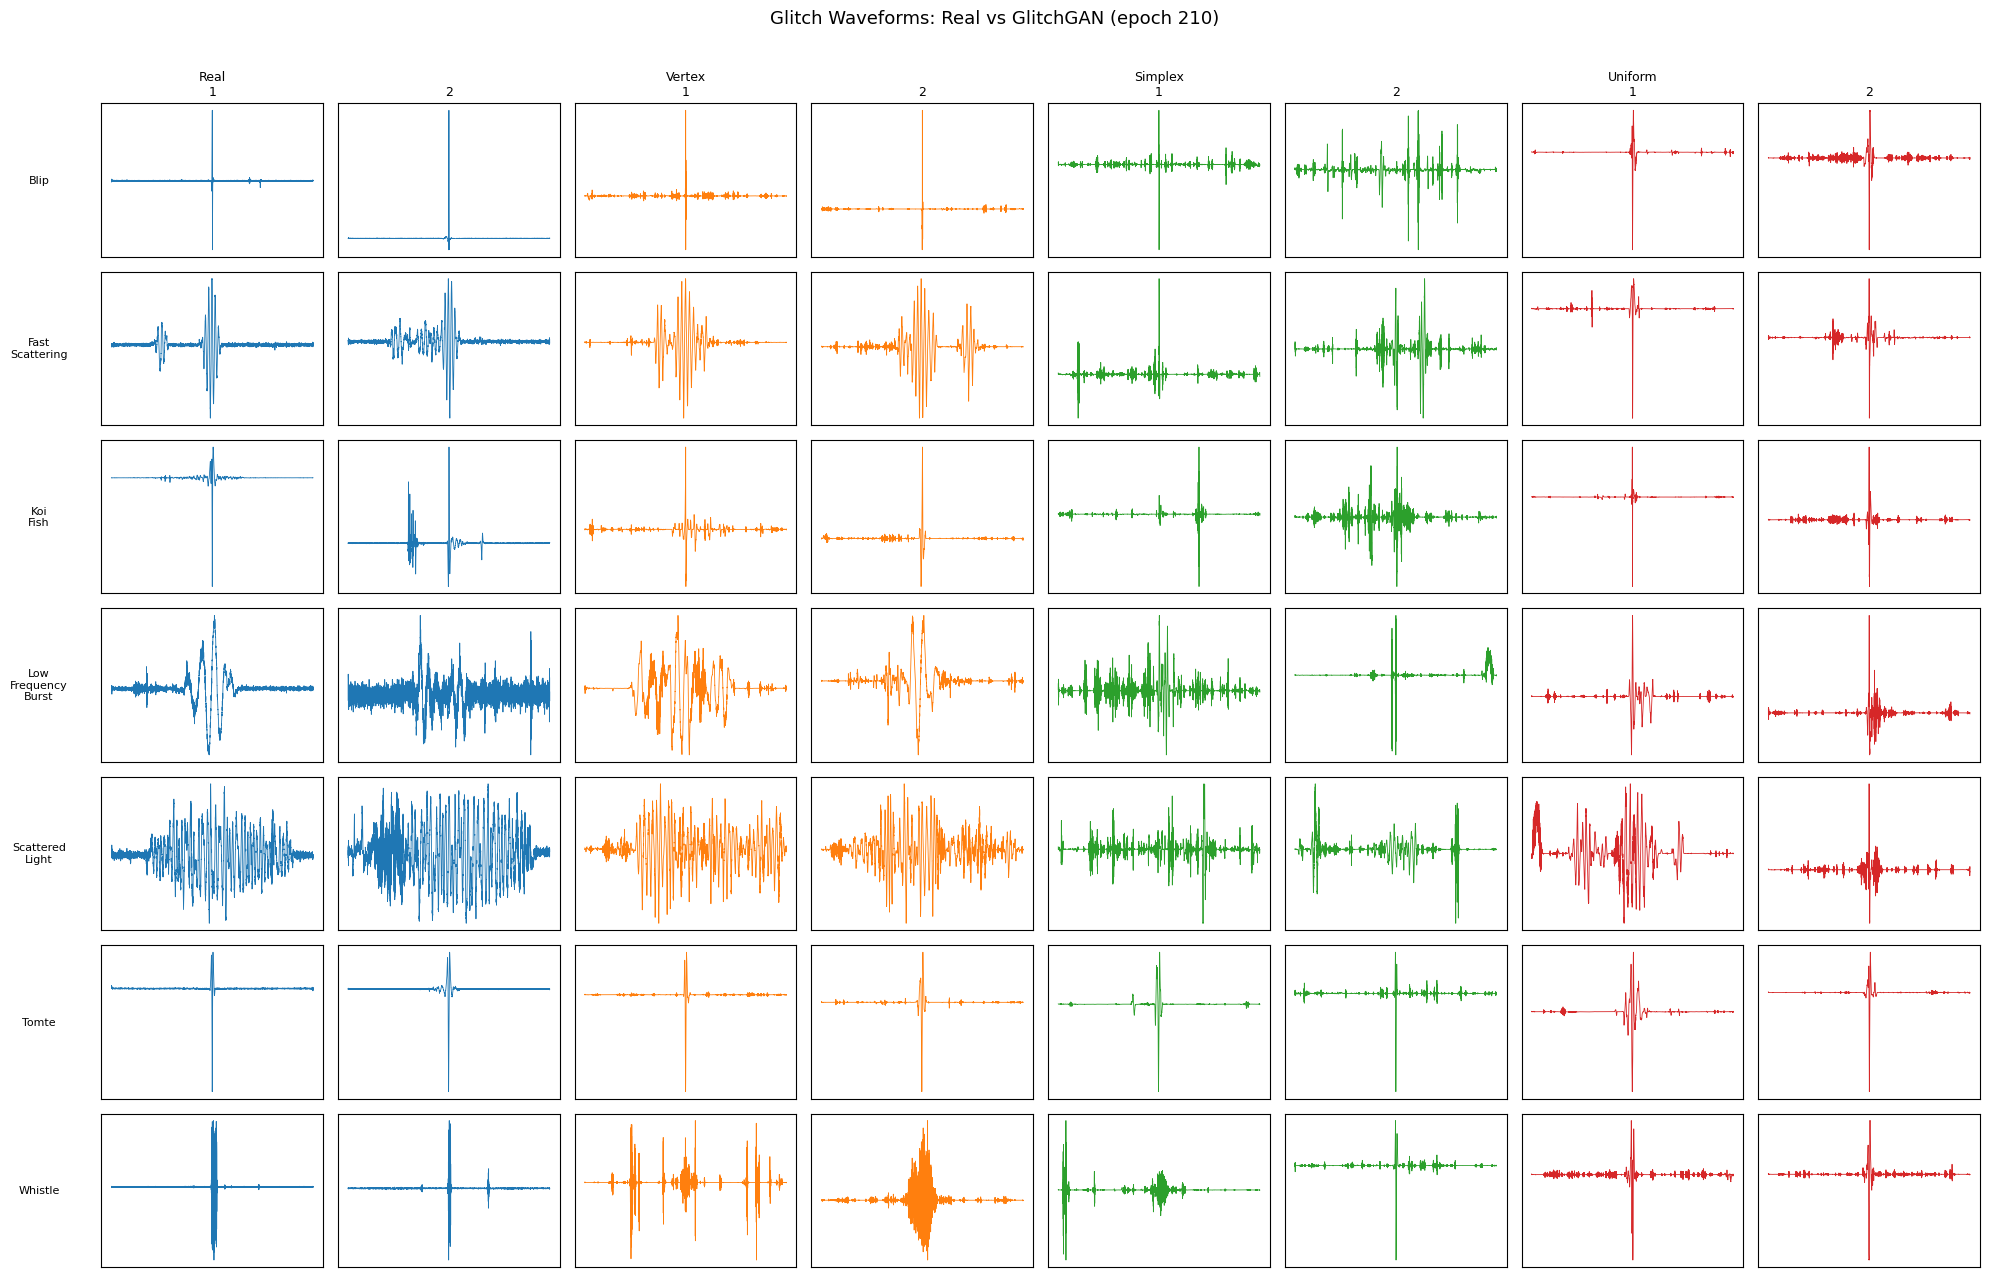

In [11]:
# 4-source comparison grid: Real / Vertex / Simplex / Uniform
plot_comparison_grid(
    sources=[
        (X_real,    y_real,    "Real",    "C0"),
        (X_fake,    y_fake,    "Vertex",  "C1"),
        (X_simplex, y_simplex, "Simplex", "C2"),
        (X_uniform, y_uniform, "Uniform", "C3"),
    ],
    label_order=LABEL_ORDER,
    n_examples=2,
    save_name=f"waveform_sampling_modes_ep{GENERATOR_EPOCH}",
)

## 4. UMAP Dimensionality Reduction

Joint 3D UMAP embedding of real and GlitchGAN-generated signals.

In [12]:
N_UMAP = 300   # samples per class per source

def subsample(X, y, label_order, n):
    idx = []
    for lbl in label_order:
        cls_idx = np.where(y == lbl)[0]
        idx.extend(np.random.choice(cls_idx, min(n, len(cls_idx)), replace=False))
    return X[idx], y[idx]

X_r_sub, y_r_sub = subsample(X_real, y_real, LABEL_ORDER, N_UMAP)
X_g_sub, y_g_sub = subsample(X_fake, y_fake, LABEL_ORDER, N_UMAP)

X_all      = np.concatenate([X_r_sub, X_g_sub], axis=0)
y_all      = np.concatenate([y_r_sub, y_g_sub], axis=0)
domain_all = np.array(["Real"] * len(X_r_sub) + ["GlitchGAN"] * len(X_g_sub))

print(f"UMAP input: {X_all.shape}")

UMAP input: (2800, 8192)


In [13]:
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.3,
    metric="euclidean",
    random_state=42,
)
embedding = reducer.fit_transform(X_all)
print(f"Embedding shape: {embedding.shape}")

/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape: (2800, 3)


In [14]:
def remove_outliers(emb, pct=1):
    lo   = np.percentile(emb, pct, axis=0)
    hi   = np.percentile(emb, 100 - pct, axis=0)
    return np.all((emb >= lo) & (emb <= hi), axis=1)

mask         = remove_outliers(embedding)
emb_clean    = embedding[mask]
y_clean      = y_all[mask]
domain_clean = domain_all[mask]
print(f"After outlier removal: {emb_clean.shape[0]} / {embedding.shape[0]} points")

After outlier removal: 2632 / 2800 points


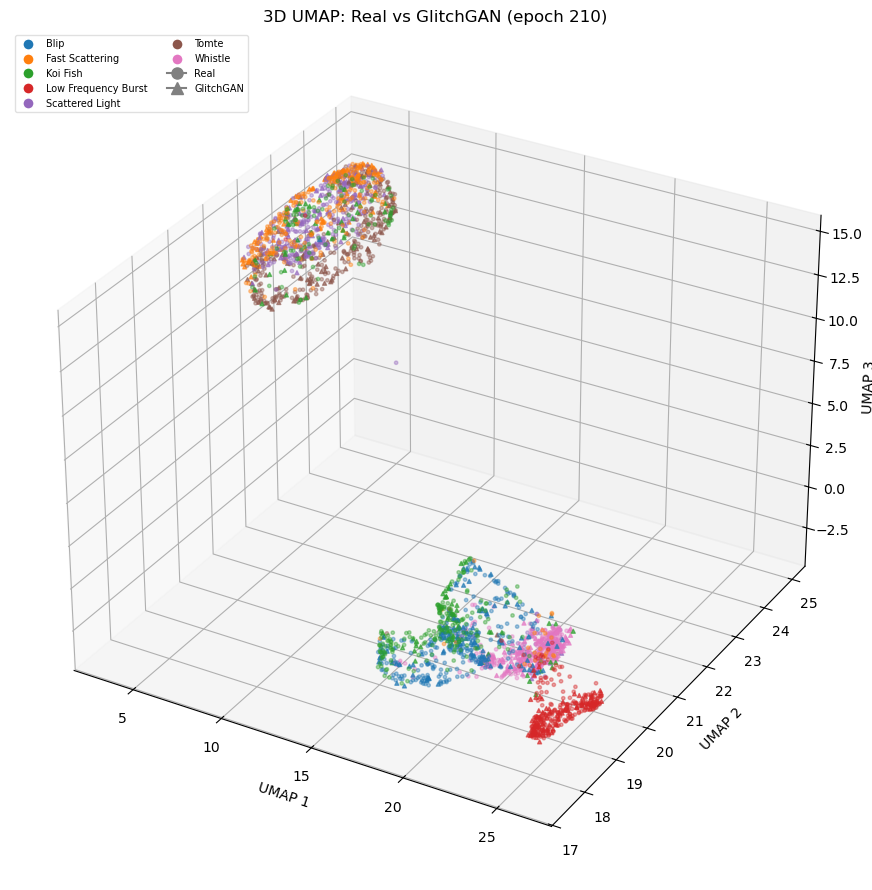

In [15]:
from matplotlib.lines import Line2D

CLASS_COLORS   = dict(zip(LABEL_ORDER, [f"C{i}" for i in range(len(LABEL_ORDER))]))
DOMAIN_MARKERS = {"Real": "o", "GlitchGAN": "^"}
DOMAIN_SIZES   = {"Real": 6,   "GlitchGAN": 8}
DOMAIN_ALPHA   = {"Real": 0.4, "GlitchGAN": 0.65}

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection="3d")

for domain in ["Real", "GlitchGAN"]:
    for lbl in LABEL_ORDER:
        m = (domain_clean == domain) & (y_clean == lbl)
        if m.sum() == 0:
            continue
        ax.scatter(
            emb_clean[m, 0], emb_clean[m, 1], emb_clean[m, 2],
            c=CLASS_COLORS[lbl], marker=DOMAIN_MARKERS[domain],
            s=DOMAIN_SIZES[domain], alpha=DOMAIN_ALPHA[domain],
        )

class_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CLASS_COLORS[lbl],
           markersize=8, label=lbl.replace("_", " "))
    for lbl in LABEL_ORDER
]
domain_handles = [
    Line2D([0], [0], marker=DOMAIN_MARKERS[d], color="grey", markersize=8, label=d)
    for d in ["Real", "GlitchGAN"]
]
ax.legend(handles=class_handles + domain_handles,
          loc="upper left", fontsize=7, ncol=2, framealpha=0.6)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_zlabel("UMAP 3")
ax.set_title(f"3D UMAP: Real vs GlitchGAN (epoch {GENERATOR_EPOCH})")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"umap_3d_glitchgan_ep{GENERATOR_EPOCH}.pdf", bbox_inches="tight")
plt.show()

### UMAP: Vertex vs Simplex vs Uniform

All three GlitchGAN sampling modes embedded alongside real signals. Vertex samples (one-hot class vectors) should cluster tightly with real signals. Simplex samples should appear within or between class clusters. Uniform samples explore the widest space.

In [16]:
X_v_sub2, y_v_sub2 = subsample(X_fake,    y_fake,    LABEL_ORDER, N_UMAP)
X_s_sub,  y_s_sub  = subsample(X_simplex, y_simplex, LABEL_ORDER, N_UMAP)
X_u_sub,  y_u_sub  = subsample(X_uniform, y_uniform, LABEL_ORDER, N_UMAP)
# Reuse X_r_sub / y_r_sub from section 4

X_all2 = np.concatenate([X_r_sub, X_v_sub2, X_s_sub, X_u_sub], axis=0)
y_all2 = np.concatenate([y_r_sub, y_v_sub2, y_s_sub, y_u_sub], axis=0)
domain_all2 = np.array(
    ["Real"]    * len(X_r_sub)  +
    ["Vertex"]  * len(X_v_sub2) +
    ["Simplex"] * len(X_s_sub)  +
    ["Uniform"] * len(X_u_sub)
)
print(f"UMAP input (all sampling modes): {X_all2.shape}")

UMAP input (all sampling modes): (4200, 8192)


In [17]:
reducer2  = umap.UMAP(
    n_components=3, n_neighbors=30, min_dist=0.3,
    metric="euclidean", random_state=42,
)
embedding2 = reducer2.fit_transform(X_all2)
print(f"Embedding shape: {embedding2.shape}")

/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding shape: (4200, 3)


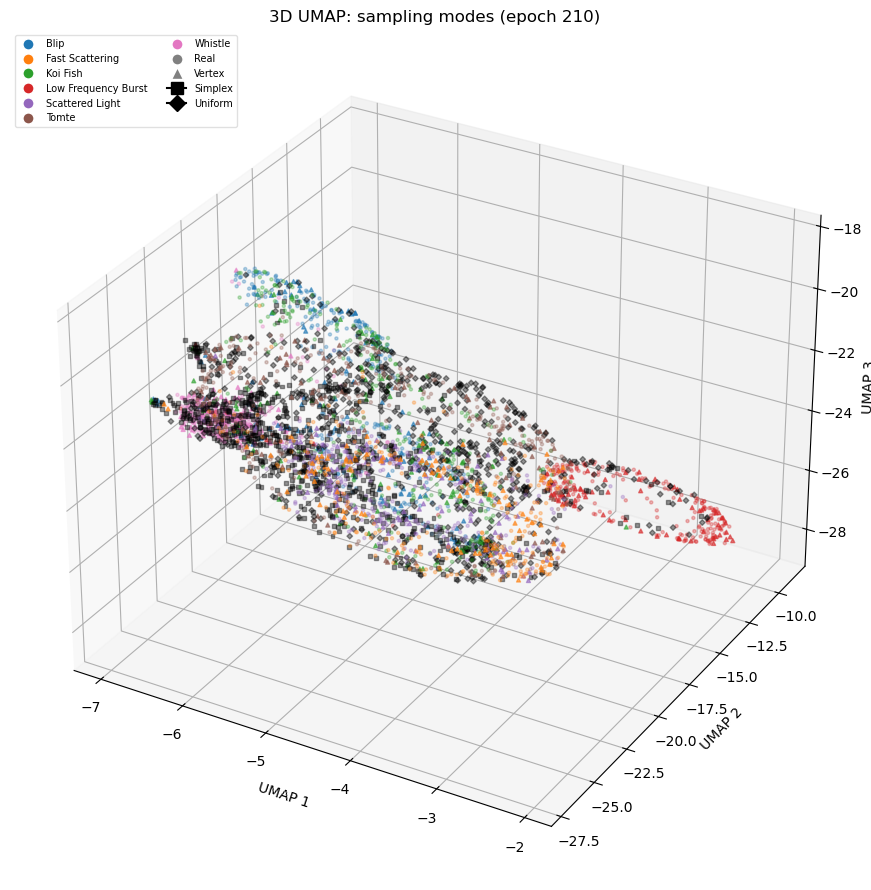

In [18]:
mask2       = remove_outliers(embedding2)
emb2        = embedding2[mask2]
y2          = y_all2[mask2]
domain2     = domain_all2[mask2]

DOMAIN_MARKERS2 = {"Real": "o", "Vertex": "^", "Simplex": "s", "Uniform": "D"}
DOMAIN_SIZES2   = {"Real": 5,   "Vertex": 8,   "Simplex": 8,   "Uniform": 8}
DOMAIN_ALPHA2   = {"Real": 0.3, "Vertex": 0.6, "Simplex": 0.4, "Uniform": 0.4}
DOMAIN_COLOR2   = {"Real": None, "Vertex": None, "Simplex": "black", "Uniform": "black"}

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection="3d")

for domain in ["Real", "Vertex", "Simplex", "Uniform"]:
    for lbl in LABEL_ORDER:
        m = (domain2 == domain) & (y2 == lbl)
        if m.sum() == 0:
            continue
        color = DOMAIN_COLOR2[domain] or CLASS_COLORS[lbl]
        ax.scatter(
            emb2[m, 0], emb2[m, 1], emb2[m, 2],
            c=color, marker=DOMAIN_MARKERS2[domain],
            s=DOMAIN_SIZES2[domain], alpha=DOMAIN_ALPHA2[domain],
        )

class_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CLASS_COLORS[lbl],
           markersize=8, label=lbl.replace("_", " "))
    for lbl in LABEL_ORDER
]
domain_handles = [
    Line2D([0], [0], marker=DOMAIN_MARKERS2[d],
           color="w" if DOMAIN_COLOR2[d] is None else DOMAIN_COLOR2[d],
           markerfacecolor=DOMAIN_COLOR2[d] or "grey",
           markersize=8, label=d)
    for d in ["Real", "Vertex", "Simplex", "Uniform"]
]
ax.legend(handles=class_handles + domain_handles,
          loc="upper left", fontsize=7, ncol=2, framealpha=0.6)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_zlabel("UMAP 3")
ax.set_title(f"3D UMAP: sampling modes (epoch {GENERATOR_EPOCH})")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"umap_sampling_modes_ep{GENERATOR_EPOCH}.pdf", bbox_inches="tight")
plt.show()

## 5. Gravity Spy Classification

Injects GlitchGAN signals into whitened background noise and classifies with the Gravity Spy CNN.

**Requirements:** `gwpy`, `gravityspy`, `pycbc`, and the Gravity Spy model file at `models/sidd-cqg-paper-O3-model.h5`.

In [19]:
# ── Gravity Spy configuration ─────────────────────────────────────────────────
IFO           = "H1"
SRATE         = 4096
GW_START      = 1262540000
GW_END        = GW_START + 40
CHANNEL       = f"{IFO}:GDS-CALIB_STRAIN"
PATH_TO_MODEL = PROJECT_ROOT / "models" / "sidd-cqg-paper-O3-model.h5"
PATH_TO_REPO  = "/home/meesde.boer/gw_learn/GravitySpy/"   # CIT path for gravityspy imports
NUM_CLASSIFY  = 10    # signals to classify per class
SNR_TARGET    = 50

In [20]:
# ── Fetch / load cached background ──────────────────────────────────────────
from gwpy.timeseries import TimeSeries

_bg_cache = PLOTS_DIR / f"strain_bg_{GW_START}_{GW_END}.hdf5"
try:
    strain_bg = TimeSeries.read(_bg_cache, format="hdf5")
    print(f"Loaded background from cache: {_bg_cache}")
except Exception:
    strain_bg = TimeSeries.fetch_open_data("H1", GW_START, GW_END)
    strain_bg = strain_bg.resample(SRATE)
    strain_bg.write(_bg_cache, format="hdf5", overwrite=True)
    print(f"Fetched and cached background: {_bg_cache}")

print(f"Background: {strain_bg.duration} s at {strain_bg.sample_rate}")

/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


Loaded background from cache: /Users/tomdooney/Documents/Work/Projects/cDVGAN_for_DeepExtractor/evaluation_plots/strain_bg_1262540000_1262540040.hdf5
Background: 40.0 s s at 4096.0 Hz


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


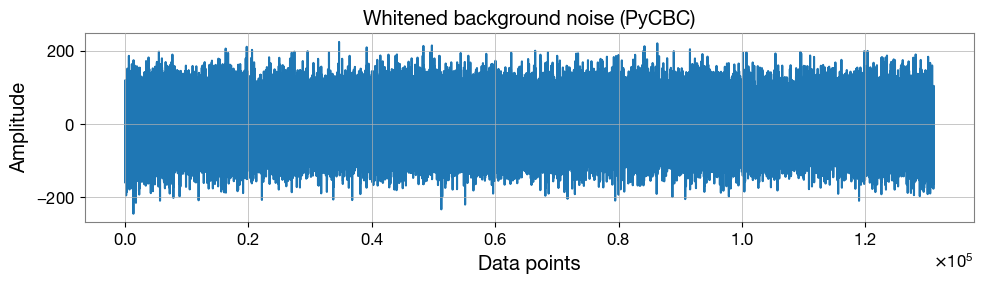

white_noise length: 163840 samples (40.0 s)


In [21]:
from pycbc.types import TimeSeries as PyCBCTimeSeries
import numpy as np
import matplotlib.pyplot as plt

# Convert gwpy TimeSeries to PyCBC
if hasattr(strain_bg, "delta_t"):
    strain_pycbc = strain_bg  # already pycbc
else:
    strain_pycbc = PyCBCTimeSeries(
        np.asarray(strain_bg, dtype="float64"),
        delta_t=1.0 / SRATE,
        epoch=GW_START,
    )

# Keep white_noise as full-length PyCBC TimeSeries — _inject_and_wrap places
# the glitch at len(bg)//2, which must correspond to EVENT_TIME=0.
# With t0=INIT_TIME=-20 and 40s at 4096 Hz: sample 81920 = t=0. Trimming
# would shift the midpoint away from EVENT_TIME and break Gravity Spy.
white_noise, psd = strain_pycbc.whiten(
    len(strain_pycbc) / (2 * SRATE),
    len(strain_pycbc) / (4 * SRATE),
    remove_corrupted=False,
    return_psd=True,
)

plt.figure(figsize=(10, 3))
plt.plot(white_noise[SRATE * 4 : -SRATE * 4])  # trim only for display
plt.xlabel("Data points")
plt.ylabel("Amplitude")
plt.title("Whitened background noise (PyCBC)")
plt.tight_layout()
plt.show()

print(f"white_noise length: {len(white_noise)} samples ({len(white_noise)/SRATE:.1f} s)")

In [22]:
import sys, warnings, logging

warnings.filterwarnings("ignore")
logging.getLogger("gravityspy").setLevel(logging.ERROR)
logging.getLogger("gwpy").setLevel(logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

sys.path.insert(0, PATH_TO_REPO)

import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
from gwpy.timeseries import TimeSeries as GWpyTimeSeries
from gravityspy.classify import classify
from cdvgan.utils import whitened_snr_scaling

INIT_TIME  = -20
EVENT_TIME = 0

def _inject_and_wrap(glitch, bg):
    id_start = len(bg) // 2 - len(glitch) // 2
    injected = bg.copy()
    injected[id_start:id_start + len(glitch)] += glitch
    return GWpyTimeSeries(injected, t0=INIT_TIME, sample_rate=SRATE, name=CHANNEL)

def classify_generated(X_gen, y_gen, label_order, tag, bg):
    rows = []
    _prev = plt.get_backend()
    plt.switch_backend("agg")
    try:
        total = sum(min(NUM_CLASSIFY, int((y_gen == lbl).sum())) for lbl in label_order)
        with tqdm(total=total, desc=f"Classifying [{tag}]", unit="glitch") as pbar:
            for lbl in label_order:
                chosen = np.random.choice(
                    np.where(y_gen == lbl)[0],
                    min(NUM_CLASSIFY, int((y_gen == lbl).sum())),
                    replace=False,
                )
                for i in chosen:
                    glitch = whitened_snr_scaling(X_gen[i], SNR_TARGET, srate=SRATE)
                    ts     = _inject_and_wrap(glitch, bg)
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        result = classify(EVENT_TIME, CHANNEL, str(PATH_TO_MODEL), timeseries=ts)
                    rows.append({"true_label": lbl,
                                 "pred_label": result["ml_label"].value[0],
                                 "confidence": result["ml_confidence"].value[0]})
                    pbar.update(1)
    finally:
        plt.switch_backend(_prev)
    return pd.DataFrame(rows)

def plot_confusion(df, tag, save_name):
    import io
    from IPython.display import Image, display as ipy_display

    if df is None:
        print(f"No results for {tag}")
        return None

    df = df[df["pred_label"] != "Error"]

    pred_all = sorted(df["pred_label"].unique())
    for lbl in LABEL_ORDER:
        if lbl not in pred_all:
            pred_all.append(lbl)
    pred_cols = (
        [lbl for lbl in LABEL_ORDER if lbl in pred_all] +
        [lbl for lbl in pred_all if lbl not in LABEL_ORDER]
    )

    count_matrix = pd.DataFrame(0, index=LABEL_ORDER, columns=pred_cols)
    conf_accum   = {(t, p): [] for t in LABEL_ORDER for p in pred_cols}

    for t, p, c in zip(df["true_label"], df["pred_label"], df["confidence"]):
        if t in LABEL_ORDER and p in pred_cols:
            count_matrix.loc[t, p] += 1
            conf_accum[(t, p)].append(c)

    annot = pd.DataFrame("", index=LABEL_ORDER, columns=pred_cols)
    for t in LABEL_ORDER:
        for p in pred_cols:
            n = count_matrix.loc[t, p]
            if n == 0:
                annot.loc[t, p] = "0"
            else:
                m = np.mean(conf_accum[(t, p)])
                annot.loc[t, p] = f"{n}\n({m:.2f})"

    acc = np.trace(count_matrix.values) / count_matrix.values.sum()

    fig_w = max(10, len(pred_cols) * 1.1)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    sns.set(style="whitegrid", font_scale=1.0)
    sns.heatmap(
        count_matrix,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": 8, "color": "black"},
        ax=ax,
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(f"Gravity Spy — {tag}   (accuracy = {acc:.1%})", fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    ipy_display(Image(buf.read()))
    print(f"{tag} accuracy: {acc:.3f}")
    return acc

INFO:panoptes_client:libmagic not operational, likely due to lack of shared libraries. Media MIME type determination will be based on file extensions.


Classifying [GlitchGAN ep210]:   0%|          | 0/70 [00:00<?, ?glitch/s]

  true_label pred_label  confidence
0       Blip       Blip    0.991039
1       Blip       Blip    0.999944
2       Blip       Blip    0.422333
3       Blip       Blip    0.999985
4       Blip       Blip    0.999979


In [26]:
df = classify_generated(X_fake, y_fake, LABEL_ORDER, f"GlitchGAN ep{GENERATOR_EPOCH}", white_noise)
df.to_csv(PLOTS_DIR / f"gspy_results_glitchgan_ep{GENERATOR_EPOCH}.csv", index=False)

acc = plot_confusion(df, f"GlitchGAN (epoch {GENERATOR_EPOCH})",
                     f"gspy_confusion_glitchgan_ep{GENERATOR_EPOCH}")

Classifying [GlitchGAN ep210]:   0%|          | 0/70 [00:00<?, ?glitch/s]

KeyboardInterrupt: 

### Load pre-saved classification results

If the classifier has already been run, reload from CSV instead.

In [28]:
df  = pd.read_csv(PLOTS_DIR / f"gspy_results_glitchgan_ep{GENERATOR_EPOCH}.csv")
acc = plot_confusion(df, f"GlitchGAN (epoch {GENERATOR_EPOCH})",
                     f"gspy_confusion_glitchgan_ep{GENERATOR_EPOCH}")

GlitchGAN (epoch 210) accuracy: 0.743


## 6. Summary

In [29]:
summary = pd.DataFrame([
    {"Model": "Real data (reference)",           "Epoch": "—",             "GravitySpy accuracy": "—"},
    {"Model": "GlitchGAN (cDVGAN, TF/Keras)",   "Epoch": GENERATOR_EPOCH, "GravitySpy accuracy": f"{acc:.3f}"},
]).set_index("Model")

print(summary.to_string())
summary.to_csv(PLOTS_DIR / f"summary_glitchgan_ep{GENERATOR_EPOCH}.csv")

                             Epoch GravitySpy accuracy
Model                                                 
Real data (reference)            —                   —
GlitchGAN (cDVGAN, TF/Keras)   210               0.743
